**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import joblib

Load Trained Model

In [3]:
MODEL_PATH = "/content/drive/MyDrive/c01-price-forecasting/models/xgboost_model.pkl"

model = joblib.load(MODEL_PATH)

print("Model loaded")
print("Model features:", model.feature_names_in_)

Model loaded
Model features: ['min_price' 'max_price' 'production_total' 'price_range' 'week_of_year'
 'week_sin' 'week_cos' 'price_4w_avg' 'price_8w_avg' 'price_change' 'year'
 'month' 'week' 'lag_1' 'lag_2' 'lag_4' 'lag_12' 'rolling_mean_4'
 'rolling_std_4' 'season_Yala' 'district_Anuradhapura'
 'district_Kurunagala' 'district_Polonnaruwa']


**Load Reference Data**

In [4]:
df = pd.read_csv("/content/drive/MyDrive/c01-price-forecasting/data/processed/cleaned_data.csv")

df['date'] = pd.to_datetime(df['date'])

print("Dataset loaded")
print(df.head())

Dataset loaded
        date district        paddy_type  min_price  max_price  avg_price  \
0 2015-03-26   Ampara  Long_Grain_White       34.0       40.0      37.14   
1 2015-04-02   Ampara  Long_Grain_White       34.0       40.0      36.40   
2 2015-04-09   Ampara  Long_Grain_White       34.0       39.0      35.68   
3 2015-04-16   Ampara  Long_Grain_White       31.0       37.0      34.97   
4 2015-04-23   Ampara  Long_Grain_White       30.0       38.0      34.03   

   production_total  price_range  week_of_year  week_sin  ...  year  month  \
0            307661          6.0            13  1.000000  ...  2015      3   
1            309335          6.0            14  0.992709  ...  2015      4   
2            309335          5.0            15  0.970942  ...  2015      4   
3            309335          6.0            16  0.935016  ...  2015      4   
4            309335          8.0            17  0.885456  ...  2015      4   

   week  lag_1  lag_2  lag_4  lag_12  rolling_mean_4  rolli

**Create Feature Generator Function**

In [5]:
def create_features(df, district, input_date):

    input_date = pd.to_datetime(input_date)

    df_d = df[df['district'] == district].copy()
    df_d = df_d.sort_values('date')
    df_d = df_d[df_d['date'] < input_date]

    if len(df_d) < 12:
        raise ValueError("Not enough historical data")

    df_last = df_d.tail(12)

    last_row = df_last.iloc[-1]

    features = {}

    # ===== TIME FEATURES =====
    features['year'] = input_date.year
    features['month'] = input_date.month
    features['week'] = input_date.isocalendar().week
    features['week_of_year'] = input_date.isocalendar().week

    # Sin/Cos encoding
    features['week_sin'] = np.sin(2 * np.pi * features['week'] / 52)
    features['week_cos'] = np.cos(2 * np.pi * features['week'] / 52)

    # ===== MARKET FEATURES =====
    features['min_price'] = last_row['min_price']
    features['max_price'] = last_row['max_price']
    features['production_total'] = last_row['production_total']

    features['price_range'] = last_row['max_price'] - last_row['min_price']

    # ===== LAG FEATURES =====
    features['lag_1'] = df_last.iloc[-1]['avg_price']
    features['lag_2'] = df_last.iloc[-2]['avg_price']
    features['lag_4'] = df_last.iloc[-4]['avg_price']
    features['lag_12'] = df_last.iloc[-12]['avg_price']

    # ===== ROLLING FEATURES =====
    features['rolling_mean_4'] = df_last['avg_price'].tail(4).mean()
    features['rolling_std_4'] = df_last['avg_price'].tail(4).std()

    # ===== AVERAGE FEATURES =====
    features['price_4w_avg'] = df_last['avg_price'].tail(4).mean()
    features['price_8w_avg'] = df_last['avg_price'].tail(8).mean()

    # ===== CHANGE FEATURE =====
    features['price_change'] = df_last.iloc[-1]['avg_price'] - df_last.iloc[-4]['avg_price']

    # ===== SEASON =====
    features['season_Yala'] = 0 if input_date.month in [9,10,11,12,1,2,3] else 1

    return features

**Prediction Function**

In [6]:
def predict_price(district, date):

    # Step 1: Create features
    features = create_features(df, district, date)

    print("\nDEBUG FEATURES:")
    for k, v in features.items():
        print(k, ":", v)

    # Step 2: Convert to DataFrame
    X_input = pd.DataFrame([features])

    # Step 3: Keep ONLY features used by XGBoost (exclude district first)
    model_features = [col for col in model.feature_names_in_ if not col.startswith("district_")]

    X_input = X_input.reindex(columns=model_features, fill_value=0)

    print("\nFeatures before district encoding:")
    print(X_input)

    # IMPORTANT: NO SCALING FOR XGBOOST

    X_final = X_input.copy()

    # Step 4: Add district one-hot encoding
    for col in model.feature_names_in_:
        if col.startswith("district_"):
            X_final[col] = 0

    district_col = f"district_{district}"

    if district_col in X_final.columns:
        X_final[district_col] = 1
    else:
        print(f"Warning: {district_col} not found in model features")

    # Step 5: Align EXACT column order
    X_final = X_final.reindex(columns=model.feature_names_in_, fill_value=0)

    print("\nFINAL INPUT TO MODEL:")
    print(X_final)

    # Step 6: Predict
    prediction = model.predict(X_final)[0]

    print("\n District:", district)
    print(" Date:", date)
    print(" Predicted Price:", round(prediction, 2))

    return prediction

**Test Section**

In [7]:
predict_price("Anuradhapura", "2026-05-01")


DEBUG FEATURES:
year : 2026
month : 5
week : 18
week_of_year : 18
week_sin : 0.8229838658936565
week_cos : -0.5680647467311557
min_price : 110.0
max_price : 115.0
production_total : 435988
price_range : 5.0
lag_1 : 112.0
lag_2 : 112.0
lag_4 : 110.8
lag_12 : 120.0
rolling_mean_4 : 111.85
rolling_std_4 : 0.7549834435270745
price_4w_avg : 111.85
price_8w_avg : 109.675
price_change : 1.2000000000000028
season_Yala : 1

Features before district encoding:
   min_price  max_price  production_total  price_range  week_of_year  \
0      110.0      115.0            435988          5.0            18   

   week_sin  week_cos  price_4w_avg  price_8w_avg  price_change  year  month  \
0  0.822984 -0.568065        111.85       109.675           1.2  2026      5   

   week  lag_1  lag_2  lag_4  lag_12  rolling_mean_4  rolling_std_4  \
0    18  112.0  112.0  110.8   120.0          111.85       0.754983   

   season_Yala  
0            1  

FINAL INPUT TO MODEL:
   min_price  max_price  production_tot

np.float32(112.057396)

**Forecast Function**

In [9]:
from datetime import timedelta

def forecast_prices(district, start_date, weeks=4):

    start_date = pd.to_datetime(start_date)

    # Get district data
    df_d = df[df['district'] == district].copy()
    df_d = df_d.sort_values('date')

    # Keep only past data
    df_d = df_d[df_d['date'] < start_date]

    if len(df_d) < 12:
        raise ValueError("Not enough historical data")

    # Work on a copy (so original df not modified)
    df_future = df_d.copy()

    predictions = []

    current_date = start_date

    for i in range(weeks):

        # Create features using current dataset
        features = create_features(df_future, district, current_date)

        X_input = pd.DataFrame([features])

        # Keep only model features (exclude district first)
        model_features = [col for col in model.feature_names_in_ if not col.startswith("district_")]
        X_input = X_input.reindex(columns=model_features, fill_value=0)

        # Add district encoding
        for col in model.feature_names_in_:
            if col.startswith("district_"):
                X_input[col] = 0

        district_col = f"district_{district}"
        if district_col in X_input.columns:
            X_input[district_col] = 1

        # Align columns
        X_input = X_input.reindex(columns=model.feature_names_in_, fill_value=0)

        # Predict
        pred = model.predict(X_input)[0]

        predictions.append({
            "date": current_date,
            "predicted_price": float(pred)
        })

        # Add prediction back into dataset
        new_row = {
            "date": current_date,
            "district": district,
            "avg_price": pred,
            "min_price": pred - 2,
            "max_price": pred + 2,
            "production_total": df_future.iloc[-1]['production_total']
        }

        df_future = pd.concat([df_future, pd.DataFrame([new_row])], ignore_index=True)

        # Move to next week
        current_date += timedelta(weeks=1)

    return pd.DataFrame(predictions)

**Test Section**

In [12]:
forecast_prices("Anuradhapura", "2026-05-21", weeks=8)

,date,predicted_price
0,2026-05-21,112.057396
1,2026-05-28,111.231583
2,2026-06-04,111.091148
3,2026-06-11,111.165825
4,2026-06-18,111.052887
5,2026-06-25,111.057320
6,2026-07-02,111.073669
7,2026-07-09,111.058014


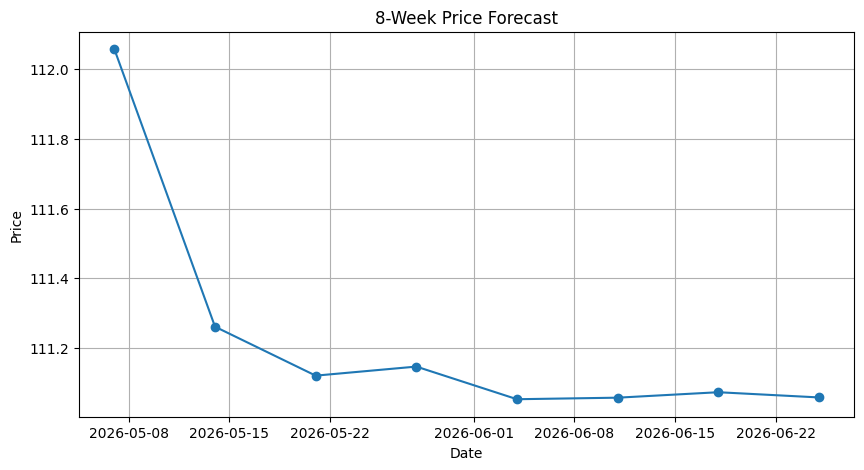

In [13]:
forecast_df = forecast_prices("Anuradhapura", "2026-05-07", weeks=8)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(forecast_df['date'], forecast_df['predicted_price'], marker='o')
plt.title("8-Week Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()